<a href="https://colab.research.google.com/github/Pasi520/Check-Heart-Risk-NN-/blob/main/train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DL/Heart-Risc(NN)/cardio_dataset.csv').values
#print(data_set[:5])

In [23]:
data = dataset[:,0:7]
target = dataset[:,7]
#print(data[:5])
#print(target[:5])

In [24]:
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler

target = np.reshape(target, (-1,1))

scaler_data = MinMaxScaler()
scaler_target = MinMaxScaler()

scaler_data.fit(data)
scaler_target.fit(target)

data_scaled = scaler_data.transform(data)
target_scaled = scaler_target.transform(target)

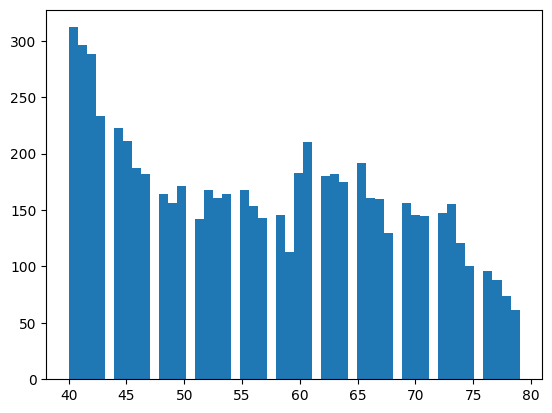

In [25]:
plt.hist(data[:,1],bins=50)
plt.show()


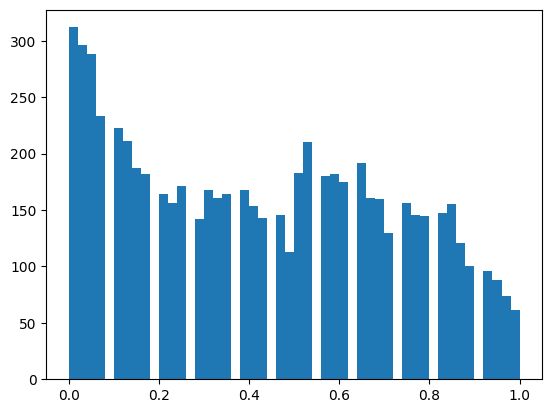

In [26]:
plt.hist(data_scaled[:,1],bins=50)
plt.show()

In [27]:
from sklearn.model_selection import train_test_split

train_data, test_data, train_target, test_target = train_test_split(data_scaled, target_scaled, test_size=0.2)

In [28]:
import keras.models as models
import keras.layers as layers
from keras.layers import Dropout
#import

model = models.Sequential()
model.add(layers.Dense(128, input_dim=7, activation='tanh'))
model.add(Dropout(0.5))
model.add(layers.Dense(64, activation='tanh'))
model.add(Dropout(0.5))
model.add(layers.Dense(10, activation='relu'))
model.add(layers.Dense(1, activation='linear'))

model.compile(optimizer='adam', loss='mse', metrics=['mse','mae'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,941 (38.83 KB)

 Trainable params: 9,941 (38.83 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history = model.fit(train_data,train_target, epochs=200,validation_split=0.2)

Epoch 1/200
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0290 - mae: 0.1167 - mse: 0.0290 - val_loss: 0.0146 - val_mae: 0.0799 - val_mse: 0.0146
Epoch 2/200
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0143 - mae: 0.0841 - mse: 0.0143 - val_loss: 0.0084 - val_mae: 0.0595 - val_mse: 0.0084
Epoch 3/200
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0108 - mae: 0.0716 - mse: 0.0108 - val_loss: 0.0059 - val_mae: 0.0491 - val_mse: 0.0059
Epoch 4/200
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0087 - mae: 0.0632 - mse: 0.0087 - val_loss: 0.0050 - val_mae: 0.0457 - val_mse: 0.0050
Epoch 5/200
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0084 - mae: 0.0607 - mse: 0.0084 - val_loss: 0.0047 - val_mae: 0.0470 - val_mse: 0.0047
Epoch 6/200
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0074 - mae: 0.0572 - mse: 0.0074 - val_loss: 0.0047 - val_mae: 0.0457 - val_mse: 0.0047
Epoch 7/200
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0069 - mae: 0.0550 - mse: 0.006

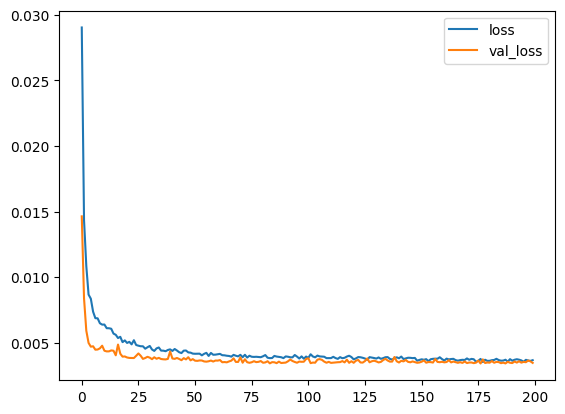

In [30]:
plt.plot(model.history.history['loss'], label='loss')
plt.plot(model.history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

In [31]:
from sklearn.metrics import r2_score

predicted_result = model.predict(test_data)

r2 = r2_score(test_target,predicted_result)
print('r2 score',r2)

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
r2 score 0.8595846493149748
